In [2]:
!pip install torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.2 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_add_pool
from torch_geometric.loader import DataLoader

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super(GAT, self).__init__()

        # First GAT layer
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)

        # Second GAT layer (concatenating results from attention heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, concat=True)

        # Third GAT layer
        self.conv3 = GATConv(hidden_channels * heads, hidden_channels, heads=1)

        # Output layers
        self.lin1 = torch.nn.Linear(hidden_channels, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        # First layer
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Second layer
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Third layer
        x = self.conv3(x, edge_index)
        x = F.relu(x)

        # Graph-level representation
        x = global_add_pool(x, batch)  # Convert to graph-level representation

        # MLP
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)

        return F.log_softmax(x, dim=1)

def train(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = F.nll_loss(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def test(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
            total += len(data.y)
    return correct / total

Processing...
Done!


Dataset: PROTEINS(1113):
Number of graphs: 1113
Number of features: 3
Number of classes: 2
Using device: cpu
Using fixed learning rate: 0.001
Epoch: 005, Loss: 0.5844, Train Acc: 0.7292, Test Acc: 0.7309, LR: 0.001000
Epoch: 010, Loss: 0.5564, Train Acc: 0.7393, Test Acc: 0.7713, LR: 0.001000
Epoch: 015, Loss: 0.5432, Train Acc: 0.7573, Test Acc: 0.7534, LR: 0.001000
Epoch: 020, Loss: 0.5473, Train Acc: 0.7663, Test Acc: 0.7713, LR: 0.001000
Epoch: 025, Loss: 0.5373, Train Acc: 0.7551, Test Acc: 0.7713, LR: 0.001000
Epoch: 030, Loss: 0.5287, Train Acc: 0.7573, Test Acc: 0.7623, LR: 0.001000
Epoch: 035, Loss: 0.5193, Train Acc: 0.7719, Test Acc: 0.7623, LR: 0.001000
Epoch: 040, Loss: 0.5199, Train Acc: 0.7663, Test Acc: 0.7668, LR: 0.001000
Epoch: 045, Loss: 0.5307, Train Acc: 0.7618, Test Acc: 0.7668, LR: 0.001000
Epoch: 050, Loss: 0.5176, Train Acc: 0.7663, Test Acc: 0.7578, LR: 0.001000
Epoch: 055, Loss: 0.5156, Train Acc: 0.7618, Test Acc: 0.7534, LR: 0.001000
Epoch: 060, Loss: 0.51

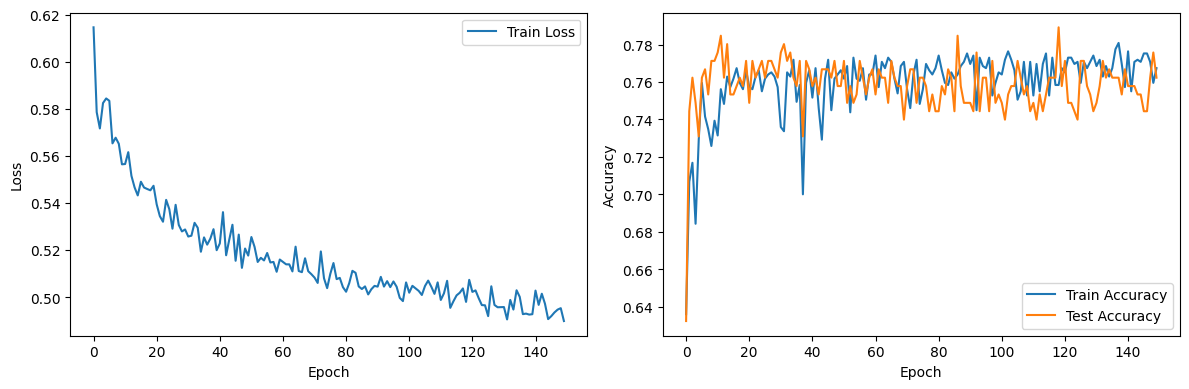

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

# Dataset selection (MUTAG -> PROTEINS)
DATASET_NAME = "PROTEINS"  # Changed to a larger dataset

# Load dataset and print basic information
dataset = TUDataset(root=f'/tmp/{DATASET_NAME}', name=DATASET_NAME)
print(f'Dataset: {dataset}:')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Shuffle and split the dataset
dataset = dataset.shuffle()
train_dataset = dataset[:int(len(dataset) * 0.8)]
test_dataset = dataset[int(len(dataset) * 0.8):]

# PROTEINS is a larger dataset, so increase batch size
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Set device (CUDA or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model setup (adjusted for larger dataset)
model = GAT(
    in_channels=dataset.num_features,
    hidden_channels=64,  # Increased hidden channel size
    out_channels=dataset.num_classes,
    heads=8,  # Increased number of heads
).to(device)

# Optimizer setup (using fixed learning rate)
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=5e-4)
print(f"Using fixed learning rate: {learning_rate}")

# Initialize variables for training and evaluation
train_losses = []
train_accs = []
test_accs = []
best_test_acc = 0

# Training and evaluation loop
for epoch in range(1, 151):  # Reduced number of epochs for larger dataset
    # Training
    loss = train(model, train_loader, optimizer, device)
    train_losses.append(loss)

    # Evaluation
    train_acc = test(model, train_loader, device)
    test_acc = test(model, test_loader, device)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Save the best performing model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), f'best_model_{DATASET_NAME}.pt')

    # Print progress
    if epoch % 5 == 0:  # More frequent output
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, '
              f'Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, '
              f'LR: {learning_rate:.6f}')

# Load the best performing model
model.load_state_dict(torch.load(f'best_model_{DATASET_NAME}.pt'))
final_test_acc = test(model, test_loader, device)
print(f'Final Test Accuracy: {final_test_acc:.4f}')

# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(f'{DATASET_NAME}_results.png')
plt.show()